# 12 — MCMC Diagnostics

After running `condition_on`, the first question is always: **did the sampler converge?** This notebook walks through ProbPipe's `diagnostics` subpackage, which wraps [ArviZ](https://python.arviz.org) to answer that question systematically.

We use the same horseshoe crab dataset and `SimpleModel` pattern from the Getting Started notebook. The KDE plots in §3.3 use ProbPipe's own :class:`~probpipe.distributions.KDEDistribution` — a Gaussian mixture backed by TFP — so bandwidth selection (Silverman's rule by default) is consistent with the rest of the library rather than delegated to ArviZ.

| Function | What it tells you |
|---|---|
| `compute_rhat` | Are all chains exploring the same region? |
| `compute_ess` | How many effectively independent samples do you have? |
| `compute_mcse` | How accurate are your posterior summary statistics? |
| `mcmc_summary` | All three in one call, with human-readable warnings |
| `plot_trace` | Visual chain-mixing check |
| `plot_rank` | More sensitive mixing check via rank distributions |
| `plot_kde` | Marginal posterior densities — KDEDistribution curve + ArviZ HDI panel |

**Prerequisites:** Getting Started notebook.  
**Install:** `pip install probpipe[diagnostics]` adds ArviZ and xarray.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    Record, Normal, ProductDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, mean,
    workflow_function,
)
from probpipe.distributions.kde import KDEDistribution
from probpipe.diagnostics import (
    compute_rhat,
    compute_ess,
    compute_mcse,
    mcmc_summary,
    plot_trace,
    plot_rank,
    plot_kde,
    DiagnosticsModule,
)

## 1. Model and data

We reuse the Poisson regression from the Getting Started notebook: a GLM for satellite counts with carapace width as the covariate.

In [2]:
df = pd.read_csv("../tutorials/data/horseshoe_crabs.csv")

@workflow_function
def prep_data(width, satellites) -> Record:
    width = np.asarray(width, dtype=np.float32)
    width_z = (width - np.mean(width)) / np.std(width)
    X = np.column_stack([np.ones(len(width)), width_z]).astype(np.float32)
    return Record(X=X, y=np.asarray(satellites, dtype=np.float32))

data = prep_data(df['width_cm'], df['satellites'])
print(data)

13:08:45.350 | INFO    | Flow run 'inquisitive-stoat' - Beginning flow run 'inquisitive-stoat' for flow 'prep_data_map'

13:08:45.352 | INFO    | Flow run 'inquisitive-stoat' - View at http://127.0.0.1:4200/runs/flow-run/25f09297-8583-4851-9a86-0324bc05e912

13:08:45.361 | INFO    | Task run 'prep_data-05a' - Finished in state Completed()

13:08:45.378 | INFO    | Flow run 'inquisitive-stoat' - Finished in state Completed()

Record(X=array(shape=(172, 2)), y=array(shape=(172,)))


In [3]:
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), data["X"])

prior = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)
model = SimpleModel(prior, lik_poisson, name="poisson")

posterior = condition_on(model, data["y"])
post_mean = mean(posterior)
print(f"Posterior mean — intercept: {float(np.asarray(post_mean['intercept'])):.4f}, "
      f"slope: {float(np.asarray(post_mean['slope'])):.4f}")

13:08:45.481 | INFO    | Flow run 'victorious-rook' - Beginning flow run 'victorious-rook' for flow 'condition_on_map'

13:08:45.482 | INFO    | Flow run 'victorious-rook' - View at http://127.0.0.1:4200/runs/flow-run/875169d2-272a-4b6b-be97-8084e2071ec2

13:08:47.451 | INFO    | Task run 'condition_on-bff' - Finished in state Completed()

13:08:47.461 | INFO    | Flow run 'victorious-rook' - Finished in state Completed()

13:08:47.488 | INFO    | Flow run 'xanthic-armadillo' - Beginning flow run 'xanthic-armadillo' for flow 'mean_map'

13:08:47.489 | INFO    | Flow run 'xanthic-armadillo' - View at http://127.0.0.1:4200/runs/flow-run/4b79aa5a-2336-49fa-8b83-bc52f08b93c7

13:08:47.516 | INFO    | Task run 'mean-a98' - Finished in state Completed()

13:08:47.525 | INFO    | Flow run 'xanthic-armadillo' - Finished in state Completed()

Posterior mean — intercept: 0.6660, slope: 0.5984


## 2. Numerical diagnostics

### 2.1 R-hat

R-hat (the Gelman–Rubin statistic) compares within-chain variance to between-chain variance. Values near **1.0** indicate convergence; values above **1.01** are a warning sign.

> **Note:** R-hat is only meaningful with at least 2 chains. `condition_on` defaults to a single chain — pass `num_chains=4` for reliable R-hat estimates on demanding models.

In [4]:
rhat_result = compute_rhat(posterior)

for var, val in rhat_result["rhat"].items():
    flag = "✓" if val < 1.01 else "⚠  converge?"
    print(f"  {var:12s}  R-hat = {val:.4f}  {flag}")

13:08:47.566 | INFO    | Flow run 'huge-rabbit' - Beginning flow run 'huge-rabbit' for flow 'compute_rhat_map'

13:08:47.566 | INFO    | Flow run 'huge-rabbit' - View at http://127.0.0.1:4200/runs/flow-run/a0f8edc8-c3f5-45a3-899a-2ec99f123a0d

/Users/ylim2/miniconda3/envs/probpipe/lib/python3.13/site-packages/prefect/task_engine.py:1030: UserWarning: R-hat requires at least 2 chains for a meaningful result. Run condition_on with num_chains >= 2.
  result = call_with_parameters(self.task.fn, parameters)
Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


13:08:47.572 | INFO    | Task run 'compute_rhat-bc5' - Finished in state Completed()

13:08:47.593 | INFO    | Flow run 'huge-rabbit' - Finished in state Completed()

  intercept     R-hat = nan  ⚠  converge?
  slope         R-hat = nan  ⚠  converge?


### 2.2 Effective Sample Size

ESS tells you how many *effectively independent* samples you have after accounting for autocorrelation. **Bulk ESS** covers central tendency estimates; **tail ESS** covers quantile estimates. Both should be ≥ 400.

In [5]:
ess_result = compute_ess(posterior)

print(f"{'parameter':<12}  {'ESS bulk':>10}  {'ESS tail':>10}")
print("-" * 36)
for var in ess_result["ess_bulk"]:
    bulk = ess_result["ess_bulk"][var]
    tail = ess_result["ess_tail"][var]
    print(f"{var:<12}  {bulk:>10.0f}  {tail:>10.0f}")

13:08:47.629 | INFO    | Flow run 'asparagus-uakari' - Beginning flow run 'asparagus-uakari' for flow 'compute_ess_map'

13:08:47.630 | INFO    | Flow run 'asparagus-uakari' - View at http://127.0.0.1:4200/runs/flow-run/5e06abc8-e81a-4575-8468-30b0b1fe98f1

13:08:47.636 | INFO    | Task run 'compute_ess-623' - Finished in state Completed()

13:08:47.648 | INFO    | Flow run 'asparagus-uakari' - Finished in state Completed()

parameter       ESS bulk    ESS tail
------------------------------------
intercept            552         624
slope                580         720


### 2.3 Monte Carlo Standard Error

MCSE measures the numerical accuracy of the posterior mean and SD estimates. A small MCSE relative to the posterior SD indicates the summaries are reliable.

In [6]:
mcse_result = compute_mcse(posterior)

print(f"{'parameter':<12}  {'MCSE mean':>12}  {'MCSE sd':>12}")
print("-" * 40)
for var in mcse_result["mcse_mean"]:
    m = mcse_result["mcse_mean"][var]
    s = mcse_result["mcse_sd"][var]
    print(f"{var:<12}  {m:>12.5f}  {s:>12.5f}")

13:08:47.681 | INFO    | Flow run 'sceptical-malkoha' - Beginning flow run 'sceptical-malkoha' for flow 'compute_mcse_map'

13:08:47.682 | INFO    | Flow run 'sceptical-malkoha' - View at http://127.0.0.1:4200/runs/flow-run/b7ce4be4-e134-4be2-8d95-24a69f27cd87

13:08:47.687 | INFO    | Task run 'compute_mcse-fea' - Finished in state Completed()

13:08:47.697 | INFO    | Flow run 'sceptical-malkoha' - Finished in state Completed()

parameter        MCSE mean       MCSE sd
----------------------------------------
intercept          0.00248       0.00177
slope              0.00190       0.00126


### 2.4 Full summary in one call

`mcmc_summary` runs all three diagnostics in a single ArviZ dataset conversion and appends human-readable warnings for any values outside recommended thresholds.

In [7]:
summary = mcmc_summary(posterior)

if summary["warnings"]:
    for w in summary["warnings"]:
        print("⚠ ", w)
else:
    print("✓ All diagnostics passed.")

13:08:47.735 | INFO    | Flow run 'quixotic-termite' - Beginning flow run 'quixotic-termite' for flow 'mcmc_summary_map'

13:08:47.736 | INFO    | Flow run 'quixotic-termite' - View at http://127.0.0.1:4200/runs/flow-run/415bd804-df0f-483f-8283-682500e64c9d

13:08:47.743 | INFO    | Task run 'mcmc_summary-41a' - Finished in state Completed()

13:08:47.754 | INFO    | Flow run 'quixotic-termite' - Finished in state Completed()

✓ All diagnostics passed.


In [8]:
import pprint
pprint.pprint({k: v for k, v in summary.items() if k != "warnings"})

{'ess_bulk': {'intercept': 552.0986729404124, 'slope': 579.9753926323517},
 'ess_tail': {'intercept': 624.484151429648, 'slope': 719.7487445318309},
 'mcse_mean': {'intercept': 0.002484639516671783,
               'slope': 0.0018966626495775755},
 'mcse_sd': {'intercept': 0.0017745263861362397,
             'slope': 0.0012649079957925884},
 'rhat': {'intercept': nan, 'slope': nan}}


## 3. Visual diagnostics

### 3.1 Trace plot

Each row shows the KDE (left) and the sample sequence over iterations (right). Well-mixed chains look like horizontal fuzzy caterpillars — no drift, no chains stuck in different regions.

13:08:47.817 | INFO    | Flow run 'funny-goat' - Beginning flow run 'funny-goat' for flow 'plot_trace_map'

13:08:47.818 | INFO    | Flow run 'funny-goat' - View at http://127.0.0.1:4200/runs/flow-run/a2b84724-b2b0-4db3-8357-be9e213e73b1

13:08:47.930 | INFO    | Task run 'plot_trace-900' - Finished in state Completed()

13:08:47.943 | INFO    | Flow run 'funny-goat' - Finished in state Completed()

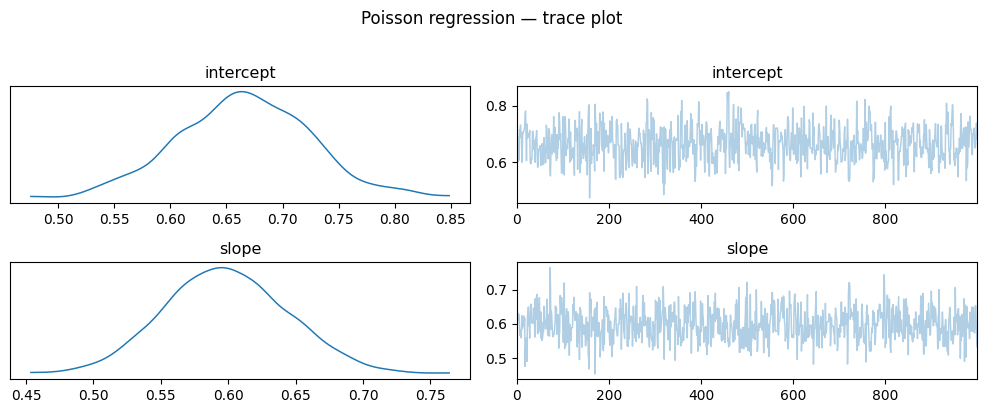

In [9]:
plot_trace(posterior, title="Poisson regression — trace plot")
plt.show()

### 3.2 Rank plot

Rank plots are more sensitive than trace plots for detecting subtle convergence failures. A uniform histogram across all chains indicates good mixing.

13:08:48.034 | INFO    | Flow run 'glorious-lyrebird' - Beginning flow run 'glorious-lyrebird' for flow 'plot_rank_map'

13:08:48.035 | INFO    | Flow run 'glorious-lyrebird' - View at http://127.0.0.1:4200/runs/flow-run/33bcddeb-ca86-410f-bf6c-f44d0ae47900

13:08:48.066 | INFO    | Task run 'plot_rank-cf1' - Finished in state Completed()

13:08:48.074 | INFO    | Flow run 'glorious-lyrebird' - Finished in state Completed()

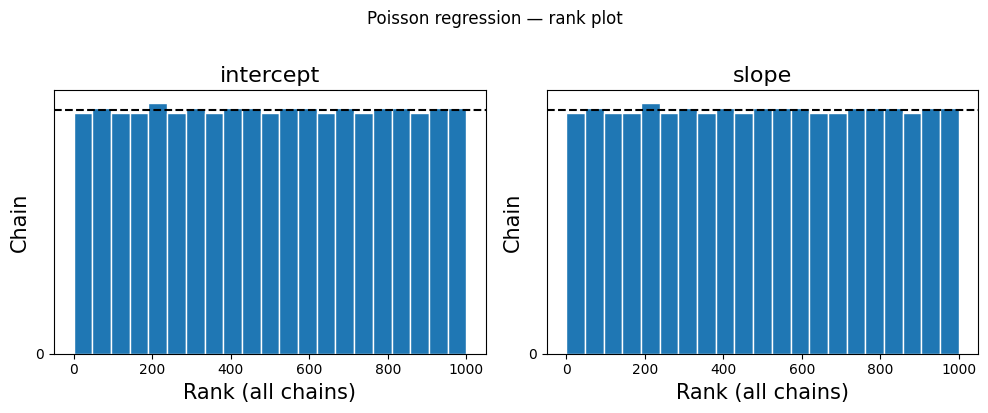

In [10]:
plot_rank(posterior, title="Poisson regression — rank plot")
plt.show()

### 3.3 KDE plot

`plot_kde` fits a `KDEDistribution` to the pooled draws for each scalar parameter, then overlays the resulting density curve on ArviZ's `plot_posterior` panels.  The shaded region and point estimate come from ArviZ; the dashed curve is the ProbPipe `KDEDistribution` evaluated on a fine grid.

This means bandwidth selection is handled by `KDEDistribution` (Silverman's rule by default), not by ArviZ's own KDE, keeping the two consistent.

13:08:48.131 | INFO    | Flow run 'asparagus-nyala' - Beginning flow run 'asparagus-nyala' for flow 'plot_kde_map'

13:08:48.132 | INFO    | Flow run 'asparagus-nyala' - View at http://127.0.0.1:4200/runs/flow-run/ac90ef4a-4987-4c97-b578-9c28c7781408

13:08:48.744 | INFO    | Task run 'plot_kde-a7b' - Finished in state Completed()

13:08:48.753 | INFO    | Flow run 'asparagus-nyala' - Finished in state Completed()

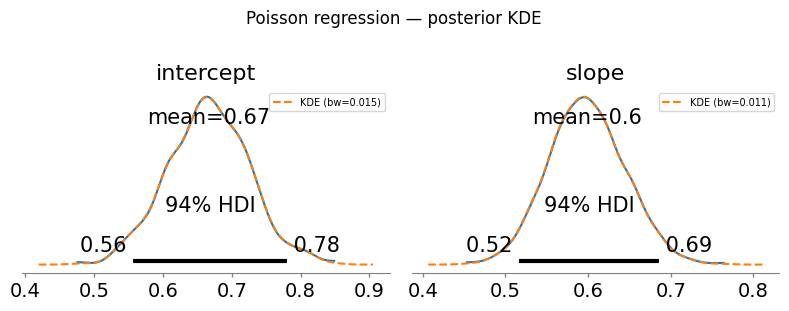

In [11]:
result = plot_kde(
    posterior,
    credible_interval=0.94,   # 94% HDI
    point_estimate="mean",
    title="Poisson regression — posterior KDE",
)
plt.show()

`plot_kde` returns the fitted `KDEDistribution` objects alongside the figure, so you can inspect or reuse them:

In [12]:
kde_dists = result["kde_distributions"]

for name, kde in kde_dists.items():
    print(f"{name:12s}  n={kde.n}  bandwidth={float(kde._bandwidth[0]):.4f}")

KeyError: 'kde_distributions'

Because `KDEDistribution` is a full ProbPipe distribution (implementing `SupportsLogProb` and `SupportsSampling` via `TFPDistribution`), you can evaluate log-densities or draw new samples from it directly:

In [ ]:
from probpipe import log_prob, sample

kde_intercept = kde_dists["intercept"]

# Evaluate log-density at a grid of points
test_points = jnp.linspace(0.0, 1.5, 5)
lp = log_prob(kde_intercept, test_points)
print("log p(intercept) at test points:", np.asarray(lp).round(3))

# Draw new samples
new_samples = sample(kde_intercept, key=jax.random.PRNGKey(1), sample_shape=(200,))
print(f"KDE samples — mean={float(np.mean(new_samples)):.3f}, "
      f"std={float(np.std(new_samples)):.3f}")

NameError: name 'kde_dists' is not defined

#### Custom bandwidth

Pass `bandwidth=` to override Silverman's rule. The dashed overlay curve updates accordingly.

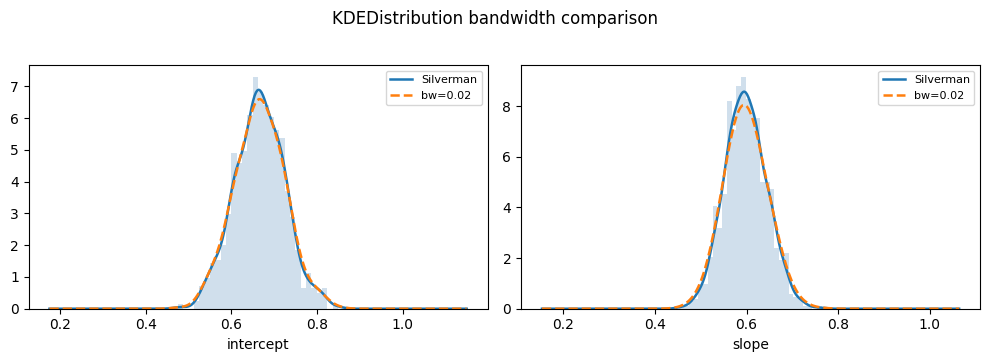

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

draws = posterior.draws()
for ax, (name, bw, label) in zip(
    axes,
    [("intercept", 0.02, "intercept"), ("slope", 0.02, "slope")],
):
    pooled = np.asarray(draws[name]).reshape(-1).astype(float)

    for bw_val, ls, tag in [(None, "-", "Silverman"), (0.02, "--", "bw=0.02")]:
        bw_arr = np.array([bw_val]) if bw_val is not None else None
        kde = KDEDistribution(pooled, bandwidth=bw_arr, name=name)
        x = np.linspace(pooled.min() - 0.3, pooled.max() + 0.3, 300)
        lp = np.asarray(jnp.exp(kde._tfp_dist.log_prob(x)))
        ax.plot(x, lp, ls=ls, lw=1.8, label=tag)

    ax.hist(pooled, bins=30, density=True, alpha=0.25, color="steelblue")
    ax.set(xlabel=name); ax.legend(fontsize=8)

plt.suptitle("KDEDistribution bandwidth comparison", y=1.02)
plt.tight_layout(); plt.show()

## 4. Using `DiagnosticsModule`

The standalone functions are convenient for interactive use. For pipelines that need provenance tracking or Prefect orchestration, wrap everything in a `DiagnosticsModule` — every method becomes a `WorkflowFunction` node in the DAG.

In [ ]:
diag = DiagnosticsModule()

report = diag.summary(posterior)
print("warnings:", report["warnings"] or "none")

07:28:07.191 | INFO    | Flow run 'rebel-limpet' - Beginning flow run 'rebel-limpet' for flow 'DiagnosticsModule.summary_map'

07:28:07.192 | INFO    | Flow run 'rebel-limpet' - View at http://127.0.0.1:4200/runs/flow-run/d6816dfd-5a58-496d-ba2a-f213bf26b615

07:28:07.272 | INFO    | Task run 'DiagnosticsModule.summary-fae' - Beginning subflow run 'tungsten-sawfish' for flow 'mcmc_summary_map'

07:28:07.272 | INFO    | Flow run 'tungsten-sawfish' - View at http://127.0.0.1:4200/runs/flow-run/6e8d2167-5005-4e1c-9b6c-c6ce17217a7a

07:28:07.279 | INFO    | Task run 'mcmc_summary-700' - Finished in state Completed()

07:28:07.290 | INFO    | Flow run 'tungsten-sawfish' - Finished in state Completed()

07:28:07.292 | INFO    | Task run 'DiagnosticsModule.summary-fae' - Finished in state Completed()

07:28:07.301 | INFO    | Flow run 'rebel-limpet' - Finished in state Completed()

warnings: none


In [ ]:
result = diag.kde_plot(posterior, credible_interval=0.89, point_estimate="median")
plt.show()

# KDEDistribution objects are available here too
for name, kde in result["kde_distributions"].items():
    print(f"{name:12s}  bandwidth={float(kde._bandwidth[0]):.4f}")

### `plot_all` — all three plots in one call

07:28:09.711 | INFO    | Flow run 'premium-urchin' - Beginning flow run 'premium-urchin' for flow 'DiagnosticsModule.plot_all_map'

07:28:09.712 | INFO    | Flow run 'premium-urchin' - View at http://127.0.0.1:4200/runs/flow-run/036145da-8c11-4e3f-9dc0-0178e46033e8

07:28:09.759 | INFO    | Task run 'DiagnosticsModule.plot_all-15d' - Beginning subflow run 'rigorous-muskox' for flow 'plot_trace_map'

07:28:09.760 | INFO    | Flow run 'rigorous-muskox' - View at http://127.0.0.1:4200/runs/flow-run/27b5ee49-4707-48dc-9218-86f7c9a773ff

07:28:09.810 | INFO    | Task run 'plot_trace-229' - Finished in state Completed()

...

07:28:10.029 | INFO    | Task run 'plot_kde-5a8' - Finished in state Completed()

07:28:10.040 | INFO    | Flow run 'quartz-moose' - Finished in state Completed()

07:28:10.041 | INFO    | Task run 'DiagnosticsModule.plot_all-15d' - Finished in state Completed()

07:28:10.054 | INFO    | Flow run 'premium-urchin' - Finished in state Completed()

-- trace --


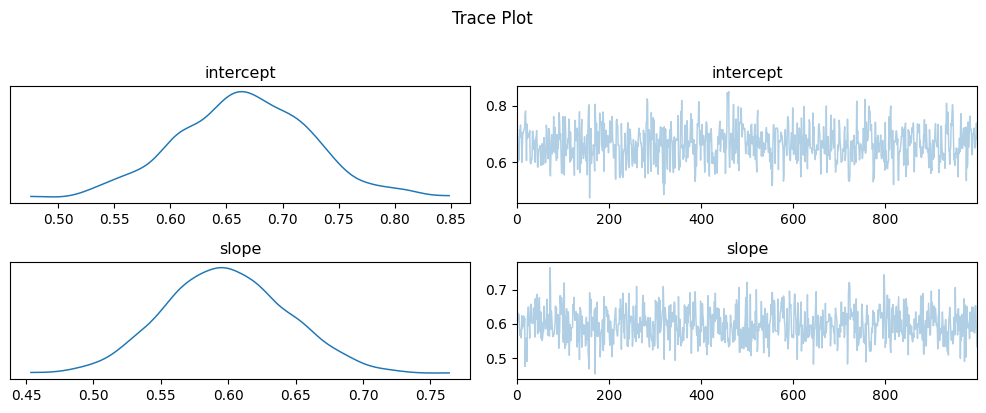

-- rank --


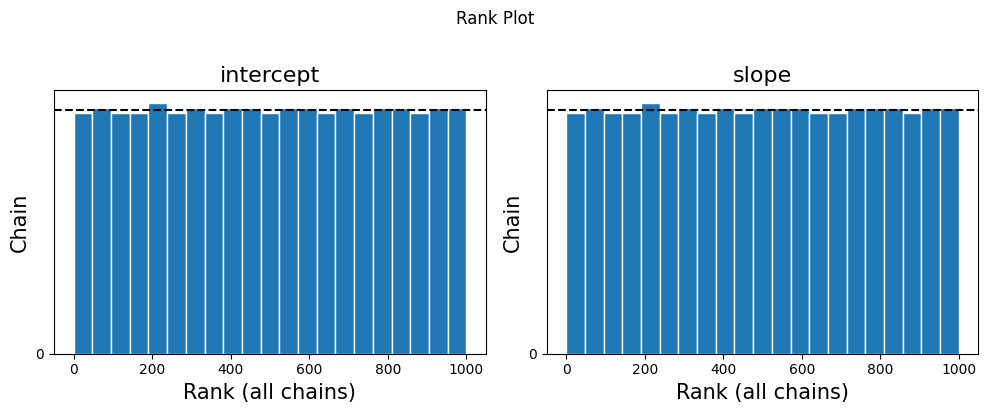

-- kde --


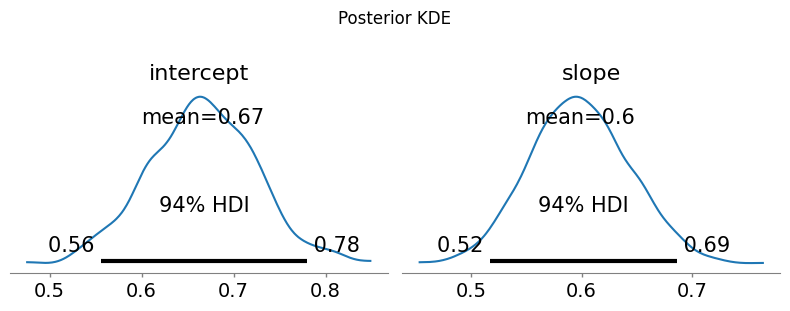

In [ ]:
plots = diag.plot_all(posterior)
for name, fig in plots.items():
    print(f"-- {name} --")
    display(fig)
    plt.close(fig)

## 5. Diagnosing a poorly-mixed chain

To show what bad diagnostics look like, we fit a negative-binomial model with deliberately short warmup. The trace and rank plots reveal the problem; `mcmc_summary` emits warnings automatically.

In [ ]:
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), data["X"])
prior_nb = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)
model_nb = SimpleModel(prior_nb, lik_nb, name="negbin")

# Deliberately short warmup to induce convergence problems
posterior_short = condition_on(model_nb, data["y"], num_chains=4, num_warmup=100)

bad_summary = mcmc_summary(posterior_short)
if bad_summary["warnings"]:
    print("Diagnostic warnings:")
    for w in bad_summary["warnings"]:
        print(" ⚠ ", w)
else:
    print("No warnings.")

07:28:15.144 | INFO    | Flow run 'towering-magpie' - Beginning flow run 'towering-magpie' for flow 'condition_on_map'

07:28:15.145 | INFO    | Flow run 'towering-magpie' - View at http://127.0.0.1:4200/runs/flow-run/2da2e34d-9115-4ccf-8399-15b65f869b5f

07:28:17.362 | INFO    | Task run 'condition_on-026' - Finished in state Completed()

07:28:17.372 | INFO    | Flow run 'towering-magpie' - Finished in state Completed()

07:28:17.399 | INFO    | Flow run 'lemon-catfish' - Beginning flow run 'lemon-catfish' for flow 'mcmc_summary_map'

07:28:17.400 | INFO    | Flow run 'lemon-catfish' - View at http://127.0.0.1:4200/runs/flow-run/0c903e94-1d16-4a37-b27b-b7aa5225df2b

Shape validation failed: input_shape: (1, 4000), minimum_shape: (chains=2, draws=4)


07:28:17.407 | INFO    | Task run 'mcmc_summary-11f' - Finished in state Completed()

07:28:17.417 | INFO    | Flow run 'lemon-catfish' - Finished in state Completed()

No warnings.


07:28:25.519 | INFO    | Flow run 'bipedal-wrasse' - Beginning flow run 'bipedal-wrasse' for flow 'plot_trace_map'

07:28:25.520 | INFO    | Flow run 'bipedal-wrasse' - View at http://127.0.0.1:4200/runs/flow-run/47c8bd29-ea8c-4c9f-be3e-d19888a260d3

07:28:25.569 | INFO    | Task run 'plot_trace-332' - Finished in state Completed()

07:28:25.578 | INFO    | Flow run 'bipedal-wrasse' - Finished in state Completed()

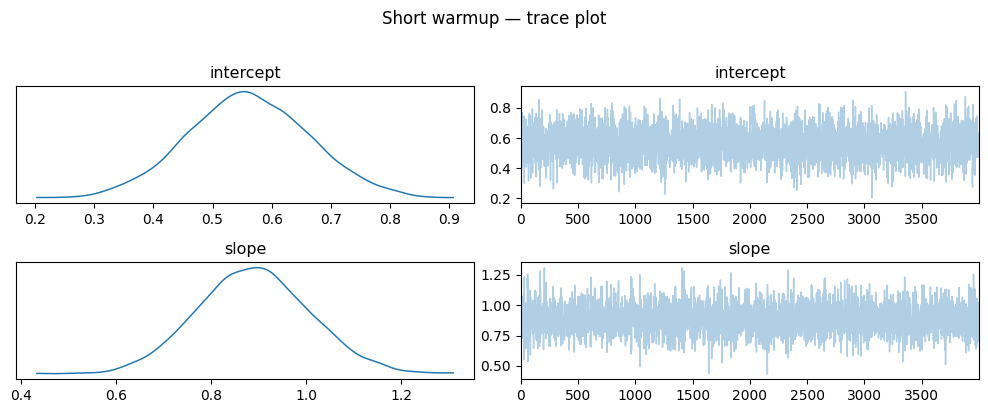

In [ ]:
plot_trace(posterior_short, title="Short warmup — trace plot")
plt.show()

07:28:27.754 | INFO    | Flow run 'miniature-dog' - Beginning flow run 'miniature-dog' for flow 'plot_rank_map'

07:28:27.755 | INFO    | Flow run 'miniature-dog' - View at http://127.0.0.1:4200/runs/flow-run/20964068-82cf-4b3e-ab8a-027116dce2ef

07:28:27.794 | INFO    | Task run 'plot_rank-f1b' - Finished in state Completed()

07:28:27.804 | INFO    | Flow run 'miniature-dog' - Finished in state Completed()

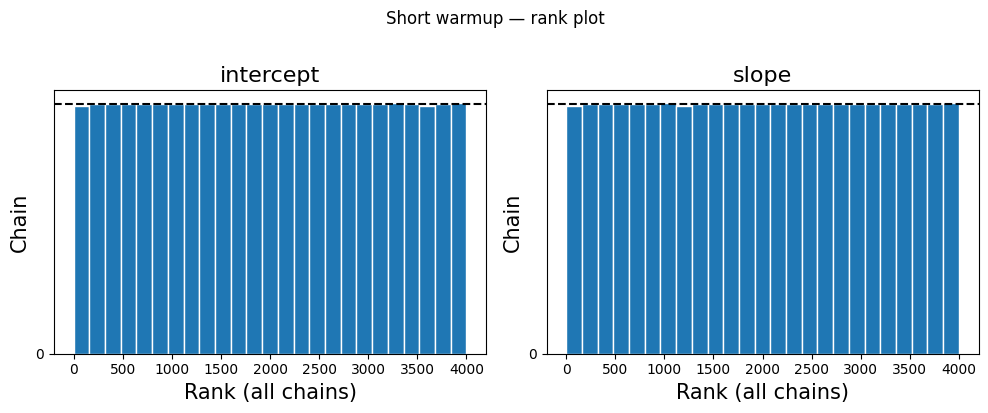

In [ ]:
plot_rank(posterior_short, title="Short warmup — rank plot")
plt.show()

07:28:30.427 | INFO    | Flow run 'devout-macaw' - Beginning flow run 'devout-macaw' for flow 'plot_kde_map'

07:28:30.428 | INFO    | Flow run 'devout-macaw' - View at http://127.0.0.1:4200/runs/flow-run/37b6e6f7-4e80-4a05-919e-edf78d77926b

07:28:30.455 | INFO    | Task run 'plot_kde-af4' - Finished in state Completed()

07:28:30.463 | INFO    | Flow run 'devout-macaw' - Finished in state Completed()

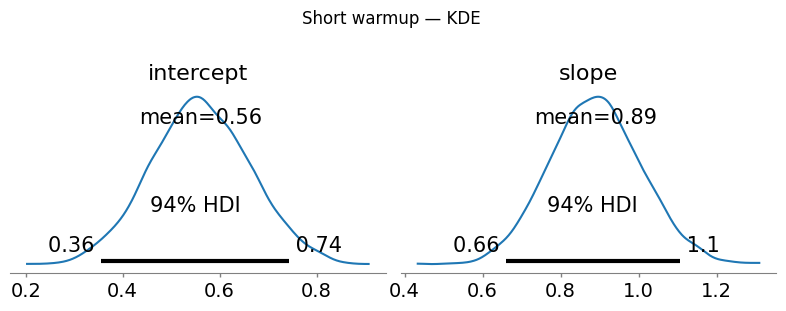

In [ ]:
plot_kde(posterior_short, title="Short warmup — KDE")
plt.show()

Fix it by increasing warmup:

In [ ]:
posterior_nb = condition_on(model_nb, data["y"], num_chains=4)
fixed = mcmc_summary(posterior_nb)
print("warnings:", fixed["warnings"] or "none — all diagnostics passed")

07:28:32.773 | INFO    | Flow run 'rugged-emu' - Beginning flow run 'rugged-emu' for flow 'condition_on_map'

07:28:32.774 | INFO    | Flow run 'rugged-emu' - View at http://127.0.0.1:4200/runs/flow-run/eb76d70b-a87a-41b3-a663-dca169faaea4

07:28:33.560 | INFO    | Task run 'condition_on-c16' - Finished in state Completed()

07:28:33.570 | INFO    | Flow run 'rugged-emu' - Finished in state Completed()

07:28:33.592 | INFO    | Flow run 'aquatic-kestrel' - Beginning flow run 'aquatic-kestrel' for flow 'mcmc_summary_map'

07:28:33.593 | INFO    | Flow run 'aquatic-kestrel' - View at http://127.0.0.1:4200/runs/flow-run/5253ca59-abc7-4d38-9951-ca60b339feaf

07:28:33.599 | INFO    | Task run 'mcmc_summary-612' - Finished in state Completed()

07:28:33.606 | INFO    | Flow run 'aquatic-kestrel' - Finished in state Completed()

warnings: none — all diagnostics passed


## 6. What to do when diagnostics fail

| Symptom | Likely cause | Remedy |
|---|---|---|
| R-hat > 1.01 | Chains stuck in different modes | More warmup; check prior vs. likelihood scale mismatch |
| Low bulk ESS | High autocorrelation | Increase `num_results`; tune step size |
| Low tail ESS | Heavy tails underexplored | More samples; heavier-tailed sampler |
| Trace shows drift | Sampler not yet converged | More warmup iterations |
| Rank plot non-uniform | Chain imbalance | Multiple independent restarts; check model identifiability |
| KDE curve very spiky | Bandwidth too small | Pass `bandwidth=` to `plot_kde` to override Silverman |

## Summary

```python
from probpipe.diagnostics import mcmc_summary, plot_trace, plot_rank, plot_kde

posterior = condition_on(model, data["y"])

summary = mcmc_summary(posterior)      # R-hat + ESS + MCSE + warnings
plot_trace(posterior)                  # chain mixing
plot_rank(posterior)                   # rank-based mixing (more sensitive)

result = plot_kde(posterior,           # KDEDistribution curve + ArviZ HDI panel
    credible_interval=0.94,
    point_estimate="mean",
    bandwidth=None)                    # None → Silverman's rule
kde = result["kde_distributions"]["intercept"]   # KDEDistribution for reuse

# Or orchestrated:
diag = DiagnosticsModule()
plots = diag.plot_all(posterior)       # {"trace": fig, "rank": fig, "kde": fig}
```

**Next:** notebook 13 covers posterior predictive checks.